## Port accessibility - real-world example

In this notebook, we set up a model for a real-world example in the Port of Rotterdam using real-world data sources. We simulate Panamax vessels with a length of 200 m and a draught of 14.65, calling at a terminal of the 3e Petroleumhaven. This terminal is a liquid bulk terminal and has two suitable jetties for this vessel type. To reach the terminal, the vessels have to navigate the Nieuwe Waterweg. Here, the vessels experience tidal windows. There assume no one-way traffic restrictions.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString
import geopandas as gpd

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr

# load OpenTNSim modules
from opentnsim.core import Identifiable, Movable, VesselProperties, ExtraMetadata
import opentnsim.fis as fis
from opentnsim.graph.mixins import HasMultiDiGraph
from opentnsim.graph.calculations import calculate_distance_along_path
from opentnsim.graph.utils import get_closest_node_to_geometry
from opentnsim.graph.visualizations import plot_graph, plot_graph_folium
from opentnsim.port.mixins.port import IsPort, HasPortAccess
from opentnsim.port.mixins.terminal import IsTerminal, HasTerminal
from opentnsim.port.mixins.berth import IsJetty, IsQuay
from opentnsim.port.mixins.anchorage_area import IsAnchorage, PassesAnchorage
from opentnsim.port.mixins import tidal_accessibility
from opentnsim.port.mixins.tidal_accessibility import HasDraughtRestrictions
from opentnsim.port.rule_constructor import vessel_characteristics, vessel_direction, vessel_type
from opentnsim.port.tidal_window_constructor import vessel_specifications, \
                                                    vertical_tidal_window_specifications, \
                                                    vertical_tidal_window_input, \
                                                    horizontal_tidal_window_specifications, \
                                                    horizontal_tidal_window_method, \
                                                    horizontal_tidal_window_input, \
                                                    tidal_period, \
                                                    accessibility, \
                                                    NetworkProperties
from opentnsim.port.rule_constructor import vessel_characteristics, vessel_direction, vessel_type
from opentnsim.port.visualizations import plot_vessels_over_route
from opentnsim.port.mixins.rules import IsRule, MathematicalOperator, VesselParameter, WaterwayParameter, ComparisonExpr, AggregateExpr, Operator
from opentnsim.port.mixins.waterway import IsWaterway, PassesWaterway
from opentnsim.environment.utils import (create_default_hydrodynamic_dataset, 
                                         add_specific_environmental_data, 
                                         add_lonlat_to_xr_dataset,
                                         interpolate_data_on_route,
                                         add_closest_node_to_xr_dataset,
                                         overwrite_data_on_node_with_data_from_another_node,
                                         set_station_value)
from opentnsim.environment.mixins.hydrodynamics import HydrodynamicData

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from pathlib import Path
import pickle
import pyproj

# package(s) needed for inspecting the output
import folium
import pandas as pd
import numpy as np
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# package(s) for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.4


In [2]:
data_path = Path.cwd() / 'data' / 'Port_accessibility'

#### 0. Create environment

In [3]:
# set simulation time
simulation_start = datetime.datetime(2026, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2026, 2, 1, 0, 0, 0)

# create time series aligned with simulation time
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
Next we create a network (a graph) along which the vessels can navigate. For this case we use the Fairway Information System graph, and consider the Port of Rotterdam.

In [4]:
# load the processed version from the Fairway Information System graph provided by Rijkswaterstaat
FG = fis.load_network(version="0.3")

We add the graph to the environment

In [5]:
env.graph = FG

And we plot the graph (warning: the plot can be demanding for your PC)

In [6]:
#plot_graph_folium(env.graph, longitude=4.25, latitude=51.95, zoom_start=11)

#### 1+ Infrastructure
We have to schematize a terminal. For this, we can download geometries of berths. For this, we use the [Havenkaart (Port Map) of the Port of Rotterdam](https://experience.arcgis.com/experience/aef5cad4ef6a437499c2ba6a7606c07b/page/Harbour-Master-Port-Map). 

##### Port
We start by creating the port itself. For simplicity, given the plot of the graph above, we take node "8866969" as our port entry.

In [7]:
port = IsPort(env=env, name = "Port of Rotterdam", port_entry_nodes=['8866969'])

##### Anchorage area
There are multiple anchorage areas in the Port of Rotterdam. They are located at sea (see [Havenkaart](https://experience.arcgis.com/experience/aef5cad4ef6a437499c2ba6a7606c07b/page/Harbour-Master-Port-Map)). For simplicity, we create a single imaginary anchorage area at the port entry with a depth of 25.0 m, which will be more than sufficient for our vessels. This will have no effect on the results.

In [8]:
anchorage_area_depth = 25.
anchorage_capacity = 20.
anchorage = IsAnchorage(env=env, capacity=anchorage_capacity, name = 'Anchorage', node = '8866969', depth = anchorage_area_depth, 
                        geometry=env.graph.nodes['8866969']['geometry'], port = port)

For one of the terminals of the 3e Petroleumhaven, we prepared a geodataframe with berths that are suitable for our vessels.

In [9]:
berth_df = gpd.read_file(data_path / "berths_PoR.geojson")
berth_df

,terminal_name,berth_name,length,depth,geometry
0,Chane,Steiger 6 Buiten,228.0,15.15,"POLYGON ((4.3095 51.88462, 4.31013 51.88455, 4..."
1,Chane,Steiger 10 Buiten,275.0,16.25,"POLYGON ((4.30963 51.87808, 4.31008 51.87816, ..."


We need to add the graph nodes to this dataframe according to the berths they are closest to. We use the "get_closest_node_to_geometry"-function of the graph module

In [10]:
berth_df['node'] = berth_df['geometry'].apply(lambda x: get_closest_node_to_geometry(env.graph,x))

We use the dataframe to create jetties that serve as berths for our terminal

In [11]:
berths = []
for _, berth in berth_df.iterrows():
    jetty = IsJetty(env=env, length=berth.length, depth=berth.depth, name=berth.berth_name,node=berth.node)
    berths.append(jetty)

We can now create the terminal

In [12]:
terminal = IsTerminal(env=env, name = berth_df.terminal_name.loc[0], berths=berths, port = port)

#### 1+ Adding environmental data
We first create a default hydrodynamic dataset for our simulation, so that we will have default data on each node.

In [13]:
hydrodynamic_data = create_default_hydrodynamic_dataset(env)
hydrodynamic_data

<xarray.Dataset> Size: 2GB
Dimensions:         (STATION: 15584, TIME: 8929)
Coordinates:
  * STATION         (STATION) <U11 686kB '8861095' '8864054' ... '22638307'
  * TIME            (TIME) datetime64[ns] 71kB 2026-01-01 ... 2026-02-01
Data variables:
    Water level     (STATION, TIME) float64 1GB 999.0 999.0 ... 999.0 999.0
    Nautical depth  (STATION, TIME) float64 1GB -999.0 -999.0 ... -999.0 -999.0

##### Water levels
Now, since we are going to model the route between the 'PortEntry' and 'Terminal', we will only add specific data for the nodes on this route. We were able to download water level data for two nearby locations using [Waterinfo from RWS](https://waterinfo.rws.nl/bulkdownload/kaart). Using another notebook located in the data-folder, we read the csv-data and stored it in a structured netCDF-file (common files to transfer hydrodynamic data).

In [14]:
wlev_data = xr.open_dataset(data_path / 'wlev_measurement_data_PoR.nc')
wlev_data

<xarray.Dataset> Size: 111kB
Dimensions:      (STATION: 2, TIME: 4609)
Coordinates:
  * STATION      (STATION) <U16 128B 'Geulhaven' 'Hoek van Holland'
  * TIME         (TIME) datetime64[ns] 37kB 2026-01-01 ... 2026-02-02
    X            (STATION) <U16 128B ...
    Y            (STATION) <U16 128B ...
    EPSG         (STATION) int64 16B ...
Data variables:
    Water level  (STATION, TIME) float64 74kB ...

We have to prepare the data, as we have to find the closest nodes in the graph of each measurement location. For this we have to tranform from the local reference system to WGS84. We created functions for this.

In [15]:
wlev_data = add_lonlat_to_xr_dataset(wlev_data)
wlev_data = add_closest_node_to_xr_dataset(wlev_data, env.graph)
wlev_data

<xarray.Dataset> Size: 111kB
Dimensions:      (STATION: 2, TIME: 4609)
Coordinates:
  * STATION      (STATION) <U7 56B '8867547' '8862426'
  * TIME         (TIME) datetime64[ns] 37kB 2026-01-01 ... 2026-02-02
    X            (STATION) <U16 128B ...
    Y            (STATION) <U16 128B ...
    EPSG         (STATION) int64 16B ...
    LON          (STATION) float64 16B 4.313 4.12
    LAT          (STATION) float64 16B 51.89 51.98
    NAME         (STATION) <U16 128B 'Geulhaven' 'Hoek van Holland'
Data variables:
    Water level  (STATION, TIME) float64 74kB ...

We can now add the data to the hydrodynamic_data

In [16]:
hydrodynamic_data = add_specific_environmental_data(hydrodynamic_data, wlev_data)
hydrodynamic_data

<xarray.Dataset> Size: 2GB
Dimensions:         (STATION: 15584, TIME: 8929)
Coordinates:
  * STATION         (STATION) <U11 686kB '8861095' '8864054' ... '22638307'
  * TIME            (TIME) datetime64[ns] 71kB 2026-01-01 ... 2026-02-01
Data variables:
    Water level     (STATION, TIME) float64 1GB 999.0 999.0 ... 999.0 999.0
    Nautical depth  (STATION, TIME) float64 1GB -999.0 -999.0 ... -999.0 -999.0

Lets check if we did well

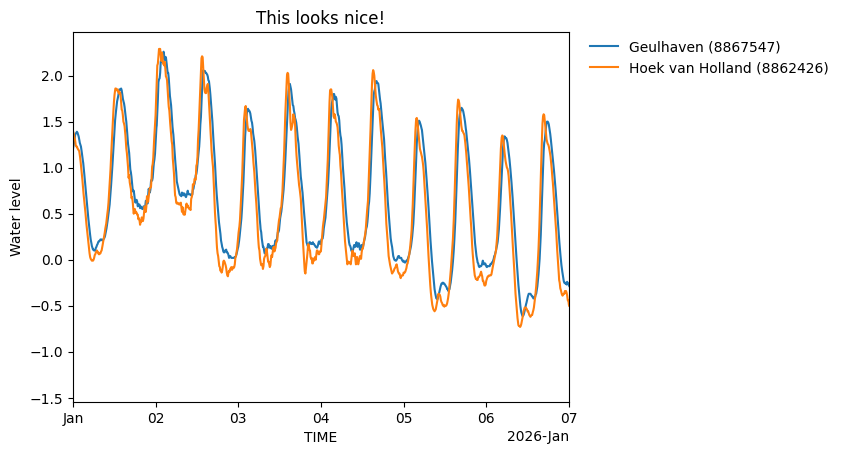

In [17]:
fig,ax = plt.subplots()
for node, name in zip(wlev_data.STATION.values,wlev_data.NAME.values):
    data = hydrodynamic_data.sel({'STATION':node})
    data["Water level"].plot(ax=ax, label=name + f' ({node})')
ax.set_xlim([pd.Timestamp('2026-01-01'),pd.Timestamp('2026-01-07')])
ax.set_title('This looks nice!')
fig.legend(loc='upper left', bbox_to_anchor=(0.925, 0.875), frameon=False, borderaxespad=0, fontsize=10);

As the last step regarding the water level data, we need to interpolate and extrapolate on the selected route. We use the folium plot of the graph for this. We see that the closest nodes of Hoek van Holland do not fall on our route, so we can validly assume that the water level on node 8862426 is the same as on node 8862925. 

In [18]:
hydrodynamic_data = overwrite_data_on_node_with_data_from_another_node(hydrodynamic_data, 
                                                                       source_station = '8862426', 
                                                                       target_station = '8862925',
                                                                       variables = ['Water level'])

We also roughly assume that the water level at Hoek van Holland is the same as at the entrance of the waterway (8866969). Therefore, we will copy the data on 8862426 to the nodes to node 8866305.

In [19]:
source_station = '8862426'
route_from_geulhaven_to_3rd_petroleumhaven = nx.dijkstra_path(env.graph, source_station, '8866969')
for target_station in route_from_geulhaven_to_3rd_petroleumhaven[1:]:  
    hydrodynamic_data = overwrite_data_on_node_with_data_from_another_node(hydrodynamic_data, 
                                                                           source_station = source_station, 
                                                                           target_station = target_station,
                                                                           variables = ['Water level'])

Similarly, we can safely assume that the water level in the 3e Petroleumhaven (until 8866999) is the same as in the Geulhaven (8867547)

In [20]:
source_station = '8867547'
route_from_geulhaven_to_3rd_petroleumhaven = nx.dijkstra_path(env.graph, source_station, '8866999')
for target_station in route_from_geulhaven_to_3rd_petroleumhaven[1:]:  
    hydrodynamic_data = overwrite_data_on_node_with_data_from_another_node(hydrodynamic_data, 
                                                                           source_station = source_station, 
                                                                           target_station = target_station,
                                                                           variables = ['Water level'])

As a last step, we will interpolate the data between Hoek van Holland (node 8862426) and the Geulhaven (node 8867547).

In [21]:
hydrodynamic_data = interpolate_data_on_route(hydrodynamic_data, 
                                              route = nx.dijkstra_path(env.graph, "8866969", "8867547"),
                                              graph = env.graph,
                                              variables = ['Water level'])

Let's check again if we successfully performed the operations.

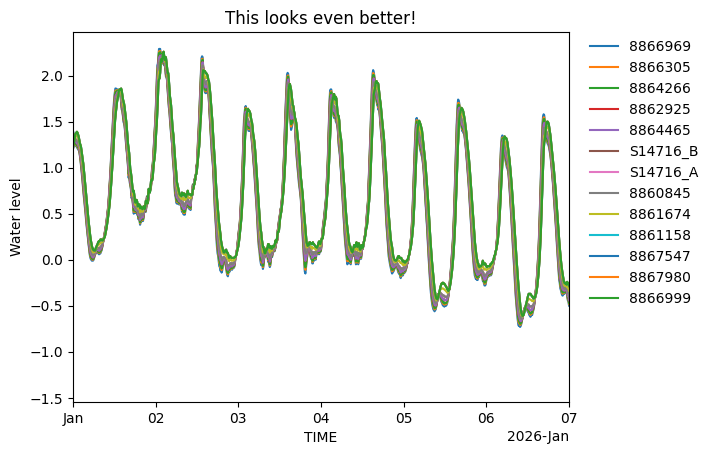

In [22]:
route_from_sea_to_terminal = nx.dijkstra_path(env.graph, '8866969','8866999')

fig,ax = plt.subplots()
for node in route_from_sea_to_terminal:
    data = hydrodynamic_data.sel({'STATION':node})
    data["Water level"].plot(ax=ax, label=node)
ax.set_xlim([pd.Timestamp('2026-01-01'),pd.Timestamp('2026-01-07')])
ax.set_title('This looks even better!')
fig.legend(loc='upper left', bbox_to_anchor=(0.925, 0.875), frameon=False, borderaxespad=0, fontsize=10);

##### Bed levels
From the [Havenkaart](https://experience.arcgis.com/experience/aef5cad4ef6a437499c2ba6a7606c07b/page/Harbour-Master-Port-Map) we can also find the nautical guaranteed depths over the route. We prepared this data.

In [23]:
depth_df = pd.read_pickle(data_path / "depth_df_PoR.pickle")
depth_df

,Nautical depth
8866969,-23.8
8866305,-16.2
8864266,-16.2
8862925,-16.2
8864465,-16.2
S14716_B,-16.2
S14716_A,-16.2
8860845,-16.2
8861674,-16.4
8861158,-16.4


We add this data to the "Nautical depth"-variable of the hydrodynamic data

In [24]:
for index, value in depth_df.iterrows():
    hydrodynamic_data = set_station_value(hydrodynamic_data,
                                          station=index,
                                          variable='Nautical depth',
                                          value = -1*value)

Final check. We will see a deep water depth at sea, and shallower varying water depths at the canal and the harbour basin.

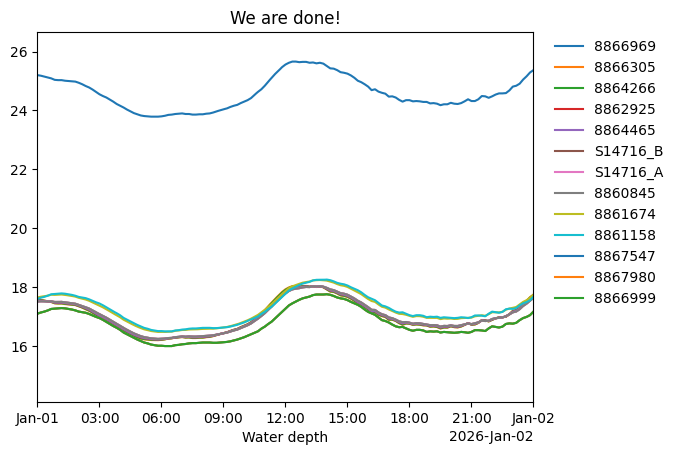

In [25]:
route_from_sea_to_terminal = nx.dijkstra_path(env.graph, '8866969','8866999')

fig,ax = plt.subplots()
for node in route_from_sea_to_terminal:
    data = hydrodynamic_data.sel({'STATION':node})
    water_depths = data["Water level"] + data["Nautical depth"]
    water_depths.plot(ax=ax, label=node)
ax.set_xlim([pd.Timestamp('2026-01-01'),pd.Timestamp('2026-01-02')])
ax.set_title('We are done!')
ax.set_xlabel('Water depth')
fig.legend(loc='upper left', bbox_to_anchor=(0.925, 0.875), frameon=False, borderaxespad=0, fontsize=10);

##### Tidal window restrictions
We need to specify the tidal window restrictions for each node. Also for this, we gather information from the Port of Rotterdam, and prepared a dataframe with data on UKC (under-keel clearance) and FWA (freshwater allowance).

In [26]:
ukc_policy_df = pd.read_pickle(data_path / 'ukc_policy_PoR.pickle')
ukc_policy_df

,ukc_p,ukc_s,fwa
8866969,0.1,0.0,0.0125
8866305,0.1,0.0,0.0125
8864266,0.1,0.0,0.0125
8862925,0.1,0.0,0.0125
8864465,0.1,0.0,0.0125
S14716_B,0.1,0.0,0.0125
S14716_A,0.1,0.0,0.0125
8860845,0.1,0.0,0.0125
8861674,0.1,0.0,0.0250
8861158,0.1,0.0,0.0250


We add the policy to the nodes along the route between the sea and the terminal

In [27]:
network_properties = NetworkProperties()
for index,node in enumerate(route_from_sea_to_terminal):
    env.graph.nodes[node]['Vertical tidal restriction'] = {}
    vertical_tidal_window_inputs = []

    vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.inbound)
    window_specification = vertical_tidal_window_specifications(ukc_s = ukc_policy_df.loc[node,'ukc_s'],
                                                                ukc_p =ukc_policy_df.loc[node,'ukc_p'],
                                                                fwa = ukc_policy_df.loc[node,'fwa'],)
    
    vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                    window_specifications = window_specification))

    network_properties.append_vertical_tidal_restriction_to_network(env.graph,node,vertical_tidal_window_inputs)

And add the data to the simulation

In [28]:
data = HydrodynamicData(env=env, hydrodynamic_data = hydrodynamic_data)

#### 2. Create agents

In [29]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (HasPortAccess,
     HasTerminal,
     PassesAnchorage,
     HasDraughtRestrictions,
     HasMultiDiGraph,
     Identifiable, # allows to give the object a name and a random ID,
     Movable,      # allows the object to move, with a fixed speed, while logging this activity
     VesselProperties,
     ExtraMetadata,# allow additional information, such as an arrival time (required for passing a lock)
    ), 
    {}
)

In [30]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    yield from vessel.move()

In [31]:
# create vessel from a dict 
data_vessel = {
    "env": env,                                      
    "name": "Vessel 1",                               
    "geometry": env.graph.nodes[route_from_sea_to_terminal[0]]['geometry'],
    "route": route_from_sea_to_terminal,              
    "v": 6,                                
    "bound": 'inbound',
    "terminal": terminal,
    "berthing_time":15, #minutes
    "loading_time": 16, #hours
    "deberthing_time":5, #minutes,
    "next_destination":route_from_sea_to_terminal[0],
    "type":"tanker",
    "L":220,
    "B":40,
    "T":14.65,
    "arrival_time":datetime.datetime(2026, 1, 4, 21, 0, 0),
} 

# create an instance of the Vessel class using the input dict data_vessel
vessel = Vessel(**data_vessel)

# start the simulation
vessel.mission = env.process(mission(env, vessel))

#### 3. Run simulation

In [32]:
env.run()

#### 4. Inspect output

In [33]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

print("'{}' logbook data:".format(vessel.name))  
print('')

display(df)

if not df.empty:
    trip_distance = calculate_distance_along_path(env.graph, vessel.route)
    trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
    print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
    print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
    print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
else:
    print("The port was not accessible for vessel")
print('')
print('')

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Waiting for Tide start,2026-01-04 21:00:00.000000,0.000000,POINT (4.04470238897276 51.99054930082)
1,Waiting for Tide stop,2026-01-05 01:45:00.000000,0.000000,POINT (4.04470238897276 51.99054930082)
2,Sailing from node 8866969 to node 8866305 start,2026-01-05 01:45:00.000000,0.000000,POINT (4.04470238897276 51.99054930082)
3,Sailing from node 8866969 to node 8866305 stop,2026-01-05 01:52:15.589365,2613.536188,POINT (4.06803280547816 51.9867838996171)
4,Sailing from node 8866305 to node 8864266 start,2026-01-05 01:52:15.589365,2613.536188,POINT (4.06803280547816 51.9867838996171)
5,Sailing from node 8866305 to node 8864266 stop,2026-01-05 01:57:06.218464,4357.310786,POINT (4.0835473317208 51.9839720592307)
6,Sailing from node 8864266 to node 8862925 start,2026-01-05 01:57:06.218464,4357.310786,POINT (4.0835473317208 51.9839720592307)
7,Sailing from node 8864266 to node 8862925 stop,2026-01-05 02:09:34.594106,8847.564637,POINT (4.12284922621524 51.97382886322)
8,Sailing from node 8862925 to node 8864465 start,2026-01-05 02:09:34.594106,8847.564637,POINT (4.12284922621524 51.97382886322)
9,Sailing from node 8862925 to node 8864465 stop,2026-01-05 02:10:01.042687,9006.256123,POINT (4.12423078527241 51.9734421732851)


'Vessel 1' travelled a distance of 23009.0 meters
'Vessel 1' took 112931.0 seconds to arrive at its destination
'Vessel 1' travelled at an average speed of 0.2 meters per second




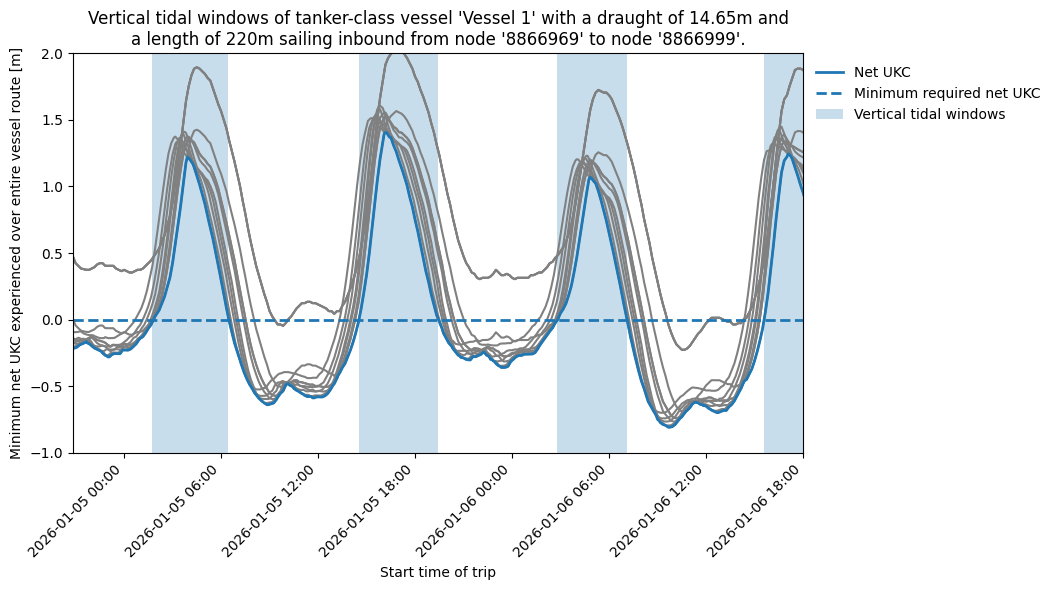

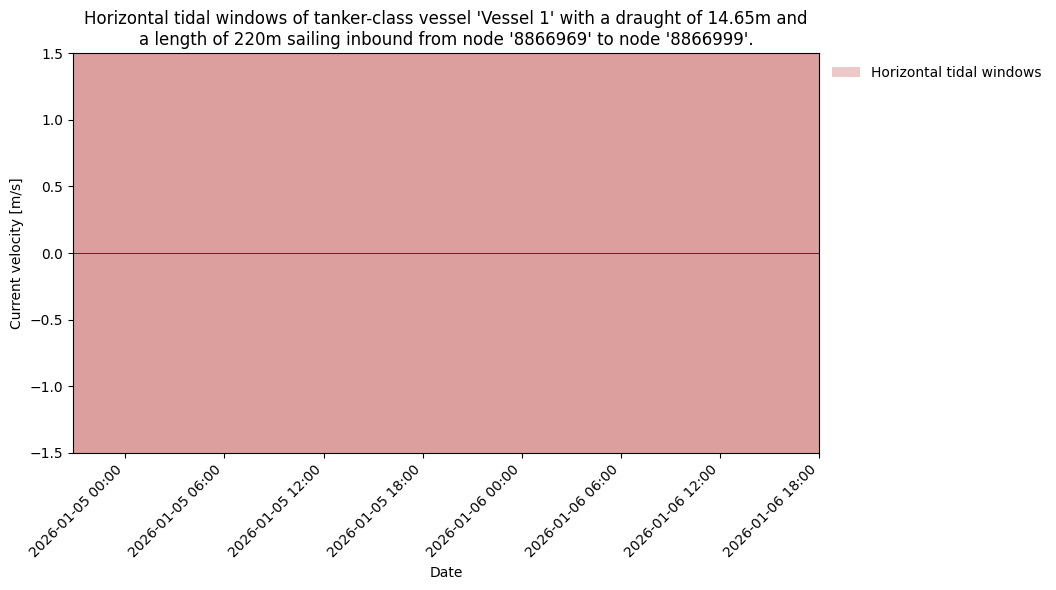

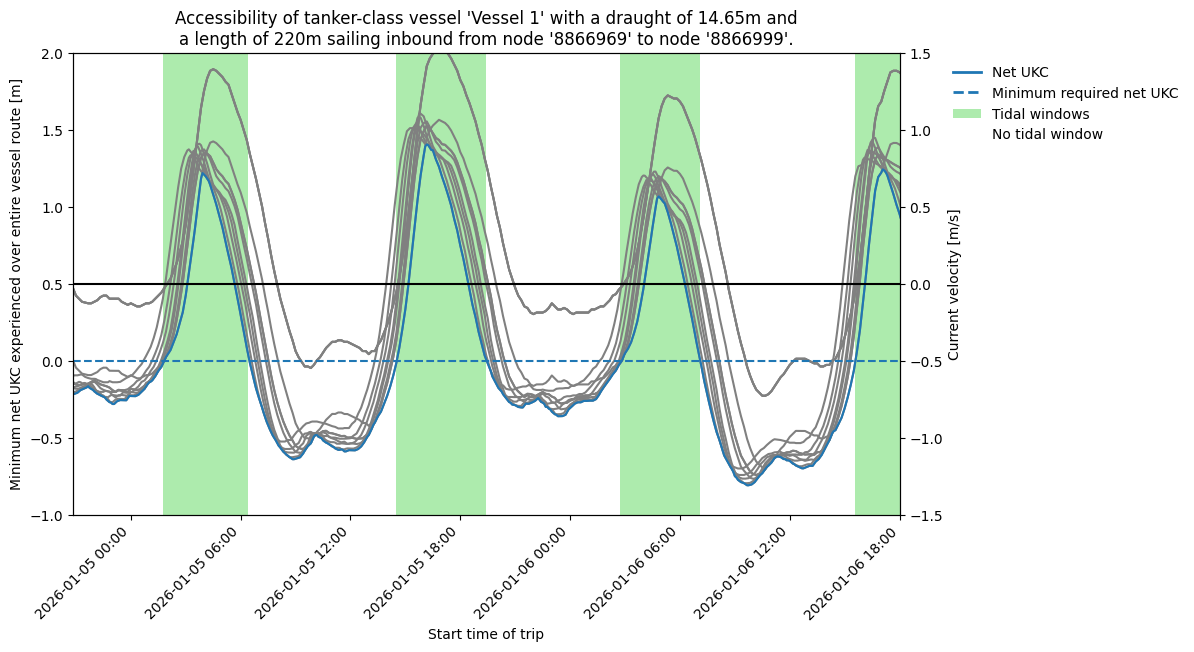

In [34]:
#Inbound trip
trip_index = 0
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig